# EUROPLANET / EPEC Research Lab — **From Signal to Scientific Decision**

### A 90-minute planetary-science practical on representations, AI, and relational information

**Scientific path**

\[
\mathrm{PLATO\text{-}like\ light\ curves}
\rightarrow \mathrm{BLS}
\rightarrow \mathrm{PANOPTICON\text{-}inspired\ event\ map}
\rightarrow \mathrm{official\ ExoMiner++\ vetting}
\rightarrow \mathrm{local\ Neural\ Process}
\rightarrow \mathrm{follow\!-\!up\ decision}.
\]

The purpose is **not** to ask which algorithm is “best.” Each method preserves a different relation in the data and answers a different scientific question.

### Learning outcomes
By the end, you should be able to:
1. explain why a strong detection statistic is not automatically a planet detection;
2. distinguish **periodic evidence**, **local event morphology**, and **multi-diagnostic vetting**;
3. explain why global CNP pooling underfits localized events and how local/attentive Neural Processes preserve context-target relations;
4. use uncertainty and disagreement to choose follow-up observations;
5. state clearly what is **official code**, what is a **classroom reimplementation**, and what is a **conceptual extension**.


## ⏱ 90-minute schedule

| Time | Activity | Scientific question |
|---|---|---|
| 0–6 min | Mission, provenance, setup | What information reaches each algorithm? |
| 6–14 min | **Data inspection — observe before you infer** | What exactly is in the simulation, and which columns are evidence versus truth? |
| 14–26 min | **Exercise 1 — BLS** | When does periodic evidence become a false positive? |
| 26–44 min | **Exercise 2 — PANOPTICON-inspired U-Net3+** | Can local morphology rescue or reject BLS candidates? |
| 44–57 min | **Exercise 3 — official NASA ExoMiner++** | Why is vetting a different problem from detection? |
| 57–72 min | **Exercise 4 — local Neural Process** | Why does locality matter for a transit? |
| 72–87 min | **Exercise 5 — Mission board** | Which five objects deserve scarce follow-up? |
| 87–90 min | Exit ticket | What should a scientifically useful representation preserve? |

### Provenance — say this explicitly in class

| Component | What this notebook uses |
|---|---|
| BLS | precomputed results from the student PLATO-like simulation pipeline |
| PANOPTICON | **PANOPTICON-inspired** 1-D U-Net3+ classroom reimplementation; **not** Vivien et al. author code or weights |
| ExoMiner++ | official NASA ExoMiner pipeline/output when cached outputs are present; no local reimplementation |
| Neural Process | a small classroom **ConvCNP-style** model; not author code. CNP failure is discussed explicitly; ANP is connected conceptually. |

This distinction is part of scientific reproducibility.


✓ EUROPLANET lab environment ready
  Python kernel : <conda-env>/bin/python
  PyTorch       : 2.14.0
  Working dir   : <repo-root>/student
  Project root  : <repo-root>
  Cases loaded  : 1457
  BLS quiet-star 95th-percentile threshold = 1.619e+04


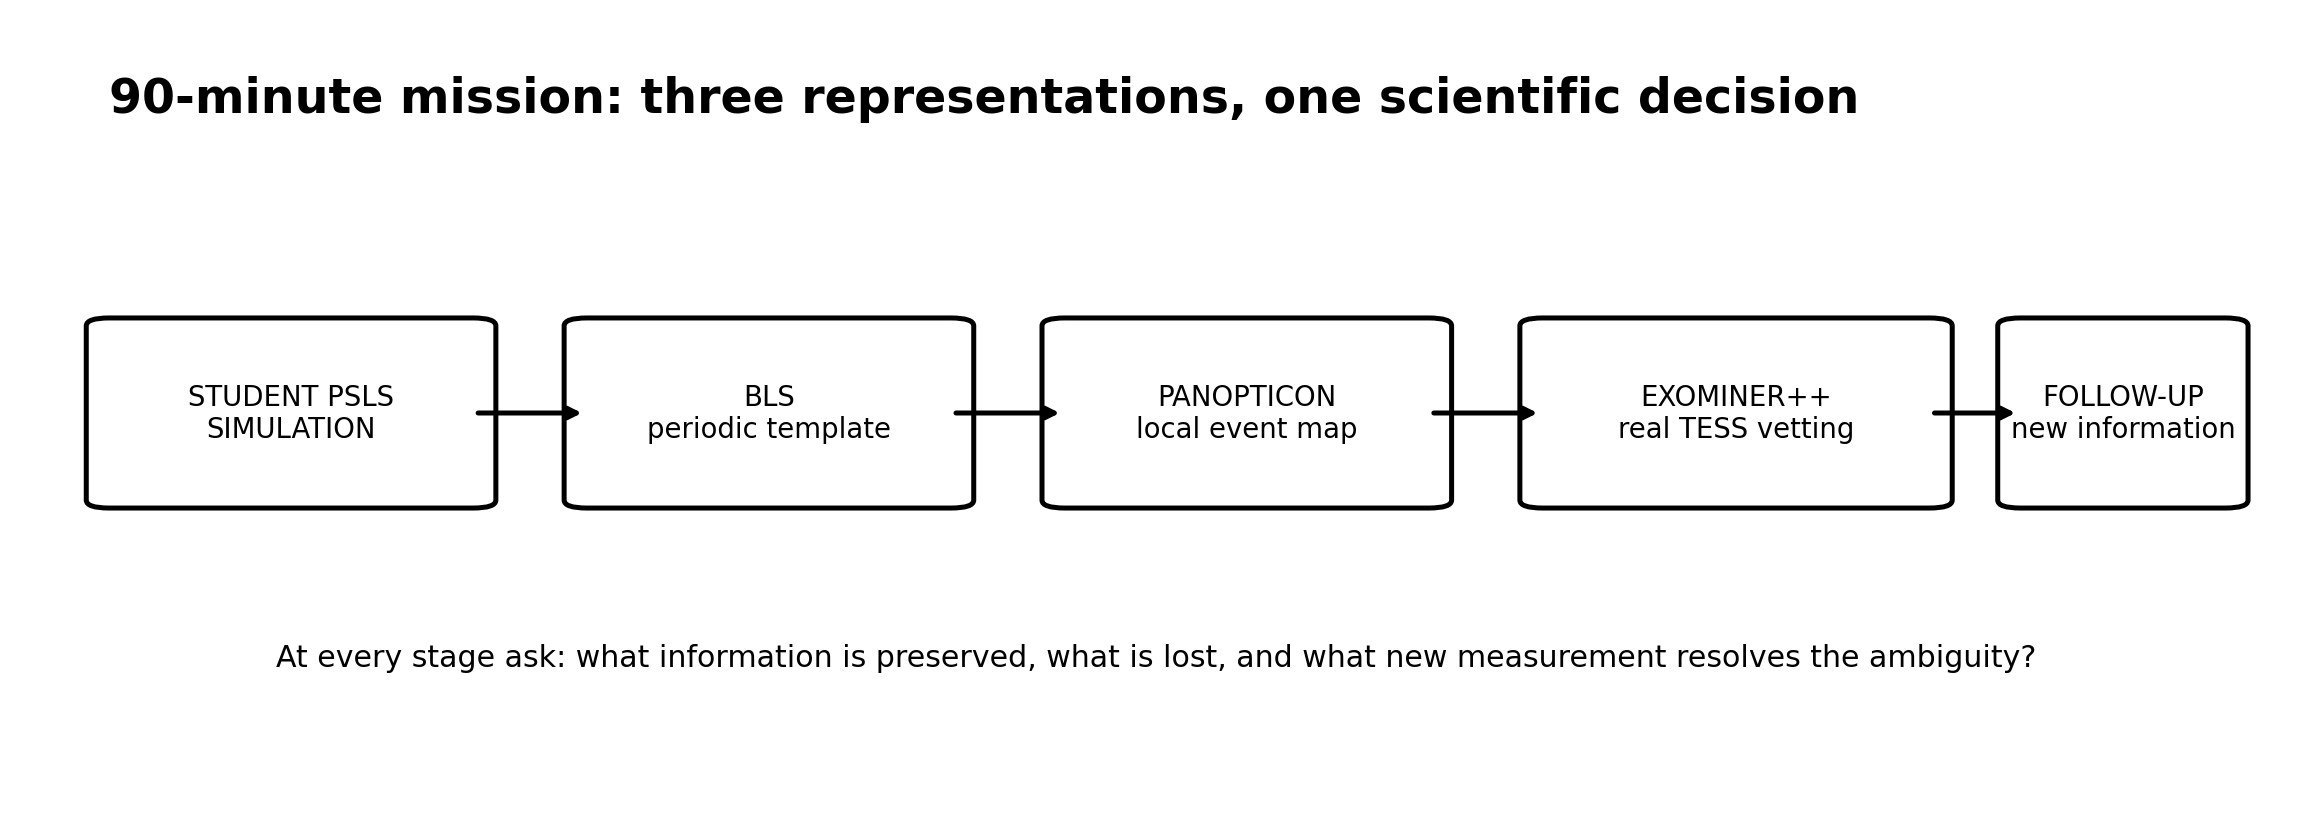

,class,meaning,N
0,0,"Quiet star, no planet",372
1,1,"Active star, no planet",358
2,2,Planet + mild activity,373
3,3,Planet + strong activity,354


In [1]:
# === PRE-FLIGHT: robust project discovery + environment check ===

from pathlib import Path
import sys, importlib.util, json, subprocess, shutil, math, time as _time

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
    'torch': 'torch',
}
_missing = [pip_name for module_name, pip_name in _REQUIRED.items()
            if importlib.util.find_spec(module_name) is None]

if _missing:
    raise ModuleNotFoundError(
        "Missing package(s) in the CURRENT Jupyter kernel: " + ", ".join(_missing) + "\n\n"
        "Active Python: " + sys.executable + "\n\n"
        "Recommended Anaconda setup:\n"
        "  conda create -n europlanet-lab python=3.11 -y\n"
        "  conda activate europlanet-lab\n"
        "  python -m pip install -r requirements.txt\n"
        "  python -m pip install ipykernel jupyterlab\n"
        "  python -m ipykernel install --user --name europlanet-lab --display-name 'EUROPLANET Lab'\n"
        "Then choose the 'EUROPLANET Lab' kernel in Jupyter."
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from IPython.display import Image, display as ipydisplay, display

def _find_lab_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents, start / 'Europlanet_ResearchLab_90min']
    for c in candidates:
        if ((c / 'europlanet_lab_utils.py').exists()
                and (c / 'data').is_dir()
                and (c / 'models').is_dir()
                and (c / 'assets').is_dir()):
            return c
    raise FileNotFoundError(
        "Cannot locate the EUROPLANET lab package root.\n"
        f"Current working directory: {start}\n"
        "Expected europlanet_lab_utils.py together with data/, models/, and assets/."
    )

ROOT = _find_lab_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR  = ROOT / 'data'
MODEL_DIR = ROOT / 'models'
ASSET_DIR = ROOT / 'assets'
EXO_DIR   = ROOT / 'exominer_official'

from europlanet_lab_utils import *

meta, bls, pan, df, BLS_THR = load_tables(ROOT)

np.random.seed(7)
torch.manual_seed(7)

print('✓ EUROPLANET lab environment ready')
print('  Python kernel :', sys.executable)
print('  PyTorch       :', torch.__version__)
print('  Working dir   :', Path.cwd().resolve())
print('  Project root  :', ROOT)
print(f'  Cases loaded  : {len(meta)}')
print(f'  BLS quiet-star 95th-percentile threshold = {BLS_THR:.4g}')

_lab_map = ASSET_DIR / 'lab_map.png'
if _lab_map.exists():
    ipydisplay(Image(filename=str(_lab_map), width=900))

display(pd.DataFrame({
    'class': [0, 1, 2, 3],
    'meaning': [CLASS_LABELS[i] for i in range(4)],
    'N': [int((meta.label == i).sum()) for i in range(4)]
}))

## 0. The information chain — **6 min**

We never classify a planet “directly.” We classify a representation produced by a measurement and compression chain:

\[
S \xrightarrow{H} X \xrightarrow{\text{representation}} Z
\xrightarrow{\text{decision rule}} \hat Y .
\]

For this practical, think of:

- \(S\): stellar + planetary physical state;
- \(H\): cadence, noise, observing window, instrumental response;
- \(X\): measured light curve / diagnostic products;
- \(Z\): BLS statistic, event map, diagnostic embedding, or NP context representation;
- \(\hat Y\): detection, vetting probability, predictive distribution, or observing decision.

### Warm-up question
Two classifiers can receive the **same photons** and disagree because they compress them differently.  
**Name one relation that BLS preserves and one relation it discards.**

> **YOUR ANSWER:**  
>

# Data inspection — **observe before you infer** **[8 min]**

Before fitting anything, inspect the measurement products and identify what is **observable**, what is **derived**, and what is available only because this is a simulation.

This package contains three different data layers:

1. **Population metadata — 1,457 simulated systems.** Stellar/activity parameters plus injected-planet truth where a planet exists.
2. **BLS results — 1,457 rows.** Outputs of the baseline transit-search analysis, joined to the metadata for evaluation.
3. **Local event windows — 100 × 512 samples.** A balanced subset used for the PANOPTICON-inspired and Neural-Process exercises.

> **Important:** the simulation truth columns are for evaluation and teaching. They are **not legitimate inference features** for a real blind search.

### Task D0.1 — inspect structure before values

Before running the next cell, predict which columns would cause **target leakage** if supplied to a transit classifier.

> **YOUR PREDICTION:**  
>


In [2]:
# === DATA INSPECTION 1: What objects and variables do we actually have? ===

local_windows = np.load(DATA_DIR / 'panopticon_eval_windows.npz')

print('Population metadata shape :', meta.shape)
print('Merged analysis table     :', df.shape)
print('Local-event window array  :', local_windows['flux'].shape)
print('Window keys               :', local_windows.files)

variable_dictionary = pd.DataFrame([
    ['file_id', 'identifier', 'bookkeeping', 'yes'],
    ['teff, logg, star_mass_msun, star_radius_rsun', 'stellar context', 'simulated/estimated physical metadata', 'context-dependent'],
    ['sigma_ppm, act_rms, rotation_period_days', 'noise/activity context', 'measurable/estimable nuisance physics', 'yes, if available'],
    ['planet_present, label', 'class truth', 'simulation truth', 'NO — target leakage'],
    ['planet_period_days, planet_radius_earth, transit_depth_ppm', 'injected planet truth', 'simulation truth for planet cases', 'NO in a blind search'],
    ['bls_period, bls_power, bls_depth_ppm', 'BLS outputs', 'derived statistics', 'yes for downstream vetting'],
    ['panopticon_event_score', 'classroom event-detector output', 'derived statistic', 'yes for downstream comparison'],
    ['mask in local_windows', 'true transit sample mask', 'simulation truth', 'NO — evaluation/training construction only'],
], columns=['variable(s)', 'role', 'provenance', 'valid blind-search input?'])

display(variable_dictionary)

preview_cols = [
    'file_id','label','activity_class','teff','logg','sigma_ppm','act_rms',
    'rotation_period_days','planet_present','planet_period_days',
    'planet_radius_earth','transit_depth_ppm'
]
display(meta[preview_cols].head(8))

# Missing values can be structural, not bad data: no-planet systems do not have planet parameters.
missing = (meta[preview_cols].isna().mean()*100).round(1).to_frame('% NaN')
display(missing)


Population metadata shape : (1457, 38)
Merged analysis table     : (1457, 60)
Local-event window array  : (100, 512)
Window keys               : ['time', 'flux', 'mask', 'file_id', 'label']


,variable(s),role,provenance,valid blind-search input?
0,file_id,identifier,bookkeeping,yes
1,"teff, logg, star_mass_msun, star_radius_rsun",stellar context,simulated/estimated physical metadata,context-dependent
2,"sigma_ppm, act_rms, rotation_period_days",noise/activity context,measurable/estimable nuisance physics,"yes, if available"
3,"planet_present, label",class truth,simulation truth,NO — target leakage
4,"planet_period_days, planet_radius_earth, trans...",injected planet truth,simulation truth for planet cases,NO in a blind search
5,"bls_period, bls_power, bls_depth_ppm",BLS outputs,derived statistics,yes for downstream vetting
6,panopticon_event_score,classroom event-detector output,derived statistic,yes for downstream comparison
7,mask in local_windows,true transit sample mask,simulation truth,NO — evaluation/training construction only


,file_id,label,activity_class,teff,logg,sigma_ppm,act_rms,rotation_period_days,planet_present,planet_period_days,planet_radius_earth,transit_depth_ppm
0,1003,2,mild,6373.3,4.310,10.54,45.443410,23.34,1,3.3447,1.26852,88.562464
1,1359,3,strong,6310.6,4.284,107.21,228.019606,18.23,1,16.6958,2.85395,426.304760
2,713,1,strong,5639.7,4.506,73.23,246.061123,16.15,0,NaN,NaN,NaN
3,316,0,mild,6162.2,4.528,12.11,42.579085,34.36,0,NaN,NaN,NaN
4,1301,3,strong,5282.6,4.317,92.52,227.908634,15.37,1,12.6726,1.43825,122.001849
5,345,0,mild,6006.9,4.327,5.65,33.699516,20.30,0,NaN,NaN,NaN
6,442,1,strong,5925.0,4.525,90.27,148.675622,12.34,0,NaN,NaN,NaN
7,787,2,mild,5312.6,4.526,13.90,62.207262,26.74,1,23.0620,1.46938,245.792937


,% NaN
file_id,0.0
label,0.0
activity_class,0.0
teff,0.0
logg,0.0
sigma_ppm,0.0
act_rms,0.0
rotation_period_days,0.0
planet_present,0.0
planet_period_days,50.1


### Task D0.2 — distinguish missingness from physics

Answer briefly:

1. Why are `planet_period_days`, `planet_radius_earth`, and `transit_depth_ppm` missing for some rows? Is that ordinary missing-data noise?
2. Name **three columns** you must never give a blind planet detector as inputs because they encode the answer.
3. Which quantities are **measurements/derived statistics**, and which are **simulation truth**?

> **YOUR ANSWER:**  
>


,class,meaning,N,median sigma_ppm,median activity RMS [ppm],median rotation [d],planet fraction,median transit depth [ppm]
0,0,"Quiet star, no planet",372,14.8,47.2,27.5,0%,nan
1,1,"Active star, no planet",358,63.0,221.2,15.5,0%,nan
2,2,Planet + mild activity,373,14.4,66.6,28.1,100%,249.1
3,3,Planet + strong activity,354,61.5,238.9,15.4,100%,278.4


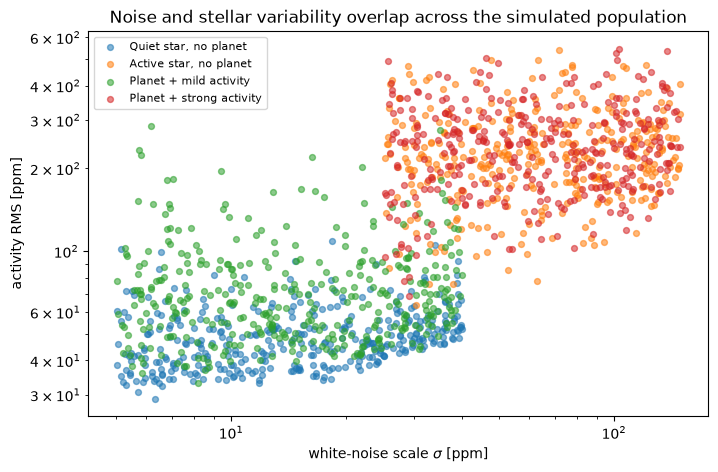

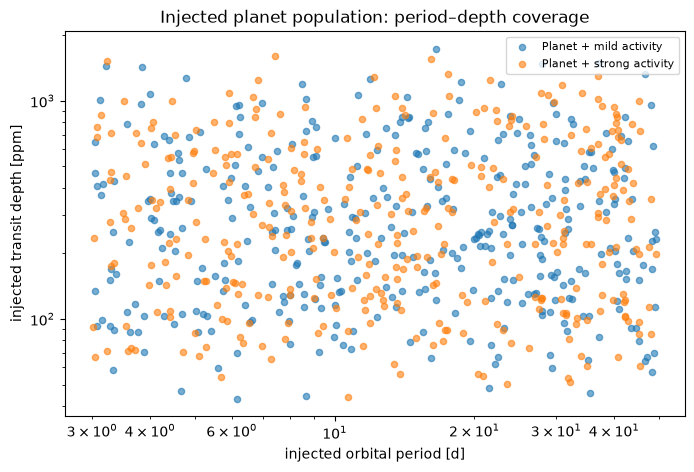

In [3]:
# === DATA INSPECTION 2: Are the four physical classes actually separable? ===

class_summary = []
for c in range(4):
    s = meta[meta.label == c]
    class_summary.append({
        'class': c,
        'meaning': CLASS_LABELS[c],
        'N': len(s),
        'median sigma_ppm': s.sigma_ppm.median(),
        'median activity RMS [ppm]': s.act_rms.median(),
        'median rotation [d]': s.rotation_period_days.median(),
        'planet fraction': s.planet_present.mean(),
        'median transit depth [ppm]': (s.loc[s.planet_present == 1, 'transit_depth_ppm'].median() if (s.planet_present == 1).any() else np.nan),
    })

display(pd.DataFrame(class_summary).style.format({
    'median sigma_ppm':'{:.1f}',
    'median activity RMS [ppm]':'{:.1f}',
    'median rotation [d]':'{:.1f}',
    'planet fraction':'{:.0%}',
    'median transit depth [ppm]':'{:.1f}'
}))

fig, ax = plt.subplots(figsize=(8,5))
for c in range(4):
    s = meta[meta.label == c]
    ax.scatter(s.sigma_ppm, s.act_rms, s=18, alpha=.55, label=CLASS_LABELS[c])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('white-noise scale $\\sigma$ [ppm]')
ax.set_ylabel('activity RMS [ppm]')
ax.set_title('Noise and stellar variability overlap across the simulated population')
ax.legend(fontsize=8)
plt.show()

planet_meta = meta[meta.planet_present == 1].copy()
fig, ax = plt.subplots(figsize=(8,5))
for c in [2,3]:
    s = planet_meta[planet_meta.label == c]
    ax.scatter(s.planet_period_days, s.transit_depth_ppm,
               s=20, alpha=.6, label=CLASS_LABELS[c])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('injected orbital period [d]')
ax.set_ylabel('injected transit depth [ppm]')
ax.set_title('Injected planet population: period–depth coverage')
ax.legend(fontsize=8)
plt.show()


### Task D0.3 — inspect overlap, not only averages

Look at the plots rather than only the medians.

1. Do activity and white-noise level cleanly separate the classes?
2. Could a classifier obtain apparently high accuracy by learning the **simulation design** rather than transit physics?
3. What split would you use to test that possibility: random rows, stellar-regime holdout, activity-regime holdout, or something else?

> **YOUR ANSWER:**  
>


N windows : 100
samples/window: 512
class counts: {0: 25, 1: 25, 2: 25, 3: 25}
median local cadence = 0.009785 d = 14.09 min
5–95% cadence range  = 14.09–14.09 min


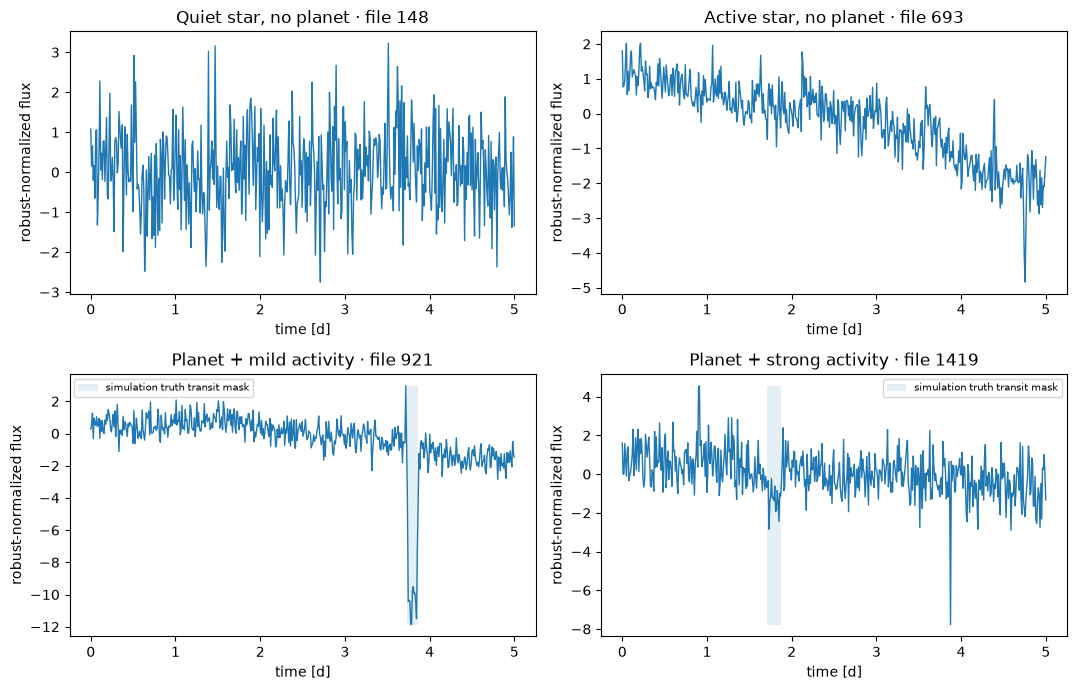

Planet-window transit duty fraction:
  median = 0.0380859375
  range  = (0.021484375, 0.07421875)


In [4]:
# === DATA INSPECTION 3: Look at the actual local light-curve representation ===

z0 = local_windows
print('N windows :', len(z0['file_id']))
print('samples/window:', z0['flux'].shape[1])
print('class counts:', {int(c): int((z0['label']==c).sum()) for c in np.unique(z0['label'])})

# Cadence inspection. These are local windows, so inspect dt rather than assuming it.
dt = np.diff(z0['time'], axis=1).ravel()
dt = dt[np.isfinite(dt) & (dt > 0)]
print(f'median local cadence = {np.median(dt):.6f} d = {np.median(dt)*24*60:.2f} min')
print(f'5–95% cadence range  = {np.percentile(dt,5)*24*60:.2f}–{np.percentile(dt,95)*24*60:.2f} min')

fig, axes = plt.subplots(2, 2, figsize=(11,7), sharex=False)
axes = axes.ravel()
for ax, c in zip(axes, range(4)):
    ids = np.where(z0['label'] == c)[0]
    q = ids[len(ids)//2]
    t = z0['time'][q]
    f = z0['flux'][q]
    truth = z0['mask'][q].astype(bool)
    ax.plot(t, f, lw=1)
    if truth.any():
        ax.fill_between(t, np.nanmin(f), np.nanmax(f), where=truth, alpha=.12,
                        label='simulation truth transit mask')
    ax.set_title(f"{CLASS_LABELS[c]} · file {int(z0['file_id'][q])}")
    ax.set_xlabel('time [d]')
    ax.set_ylabel('robust-normalized flux')
    if truth.any(): ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# How much of each local window is actually transit for planet cases?
planet_win = z0['label'] >= 2
transit_fraction = z0['mask'][planet_win].mean(axis=1)
print('Planet-window transit duty fraction:')
print('  median =', float(np.median(transit_fraction)))
print('  range  =', (float(np.min(transit_fraction)), float(np.max(transit_fraction))))


### Task D0.4 — representation audit

1. What information has already been lost when a long irregular light curve is reduced to a 512-sample local window?
2. Why is the **truth transit mask** useful for evaluation but scientifically invalid as a blind-search input?
3. Pick one displayed window. What could fool a box model? What could fool a local morphology model?
4. Does inspecting four examples establish generalization? What population-level check would you demand next?

> **YOUR ANSWER:**  
>


# Exercise 1 — BLS: a detection statistic is not “the truth” **[12 min]**

The baseline represented in these tables used a classical transit-search logic: detrending/aggregation followed by **Box Least Squares**. The decision threshold is set from the quiet no-planet population.

A useful detection statistic can still be confounded if an unmodelled process projects strongly onto its template family.

### Task 1A
Measure how often BLS crosses the quiet-star threshold in each physical class.

### Prediction before running the cell
Which class should generate the largest **false-positive rate**, and why?

> **YOUR PREDICTION:**  
>

,class,meaning,N,BLS above threshold,period match,recovered
0,0,"Quiet star, no planet",372,5.1%,nan%,nan%
1,1,"Active star, no planet",358,90.5%,nan%,nan%
2,2,Planet + mild activity,373,98.4%,96.2%,96.0%
3,3,Planet + strong activity,354,100.0%,89.5%,89.5%


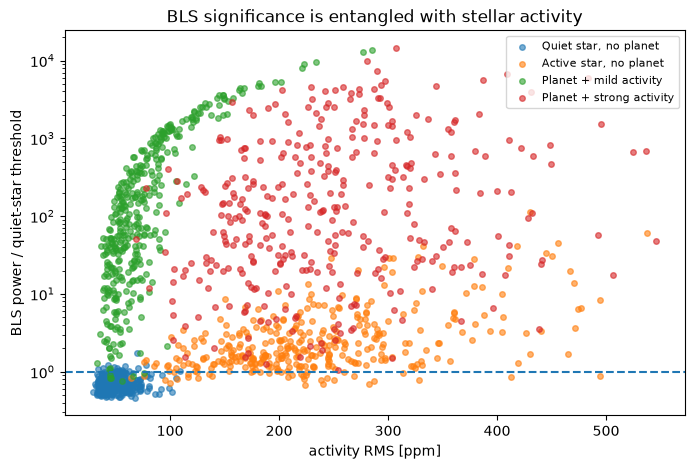

In [5]:
rows = []
for c in range(4):
    s = df[df.label == c]
    rows.append({
        'class': c,
        'meaning': CLASS_LABELS[c],
        'N': len(s),
        'BLS above threshold': s.bls_flag_recalc.mean(),
        'period match': np.nan if c < 2 else s.period_match.mean(),
        'recovered': np.nan if c < 2 else (s.bls_flag_recalc & s.period_match).mean()
    })

audit = pd.DataFrame(rows)
display(audit.style.format({
    'BLS above threshold': '{:.1%}',
    'period match': '{:.1%}',
    'recovered': '{:.1%}'
}))

fig, ax = plt.subplots(figsize=(8,5))
for c in range(4):
    s = df[df.label == c]
    ax.scatter(s.act_rms, s.bls_power_ratio, s=16, alpha=.6, label=CLASS_LABELS[c])
ax.axhline(1, ls='--')
ax.set_yscale('log')
ax.set_xlabel('activity RMS [ppm]')
ax.set_ylabel('BLS power / quiet-star threshold')
ax.legend(fontsize=8)
ax.set_title('BLS significance is entangled with stellar activity')
plt.show()

### Task 1B — interpretation

Answer in **2–3 sentences**:

1. Why is “high BLS power” not sufficient evidence for a planet?
2. What information does a period search deliberately compress away?
3. Does changing the threshold solve the activity problem, or merely move the sensitivity–specificity trade-off?

> **YOUR ANSWER:**  
>

# Exercise 2 — PANOPTICON-inspired U-Net3+: change the question **[18 min]**

Vivien et al. developed PANOPTICON for **single-event transit detection in unfiltered PLATO-like light curves**. Its key conceptual shift is:

\[
\text{“What periodic box fits the whole light curve?”}
\quad\longrightarrow\quad
\text{“Where is transit-like morphology?”}
\]

The published method uses the 1-D U-Net family and reports U-Net3+ as the strongest variant.

> **Provenance warning:** the model below is a **classroom PANOPTICON-inspired U-Net3+ reimplementation following the published design**. It is **not the authors' original code and not their released weights**.

### Task 2A
Inspect two local event maps: a planet in strong activity and an active no-planet star.

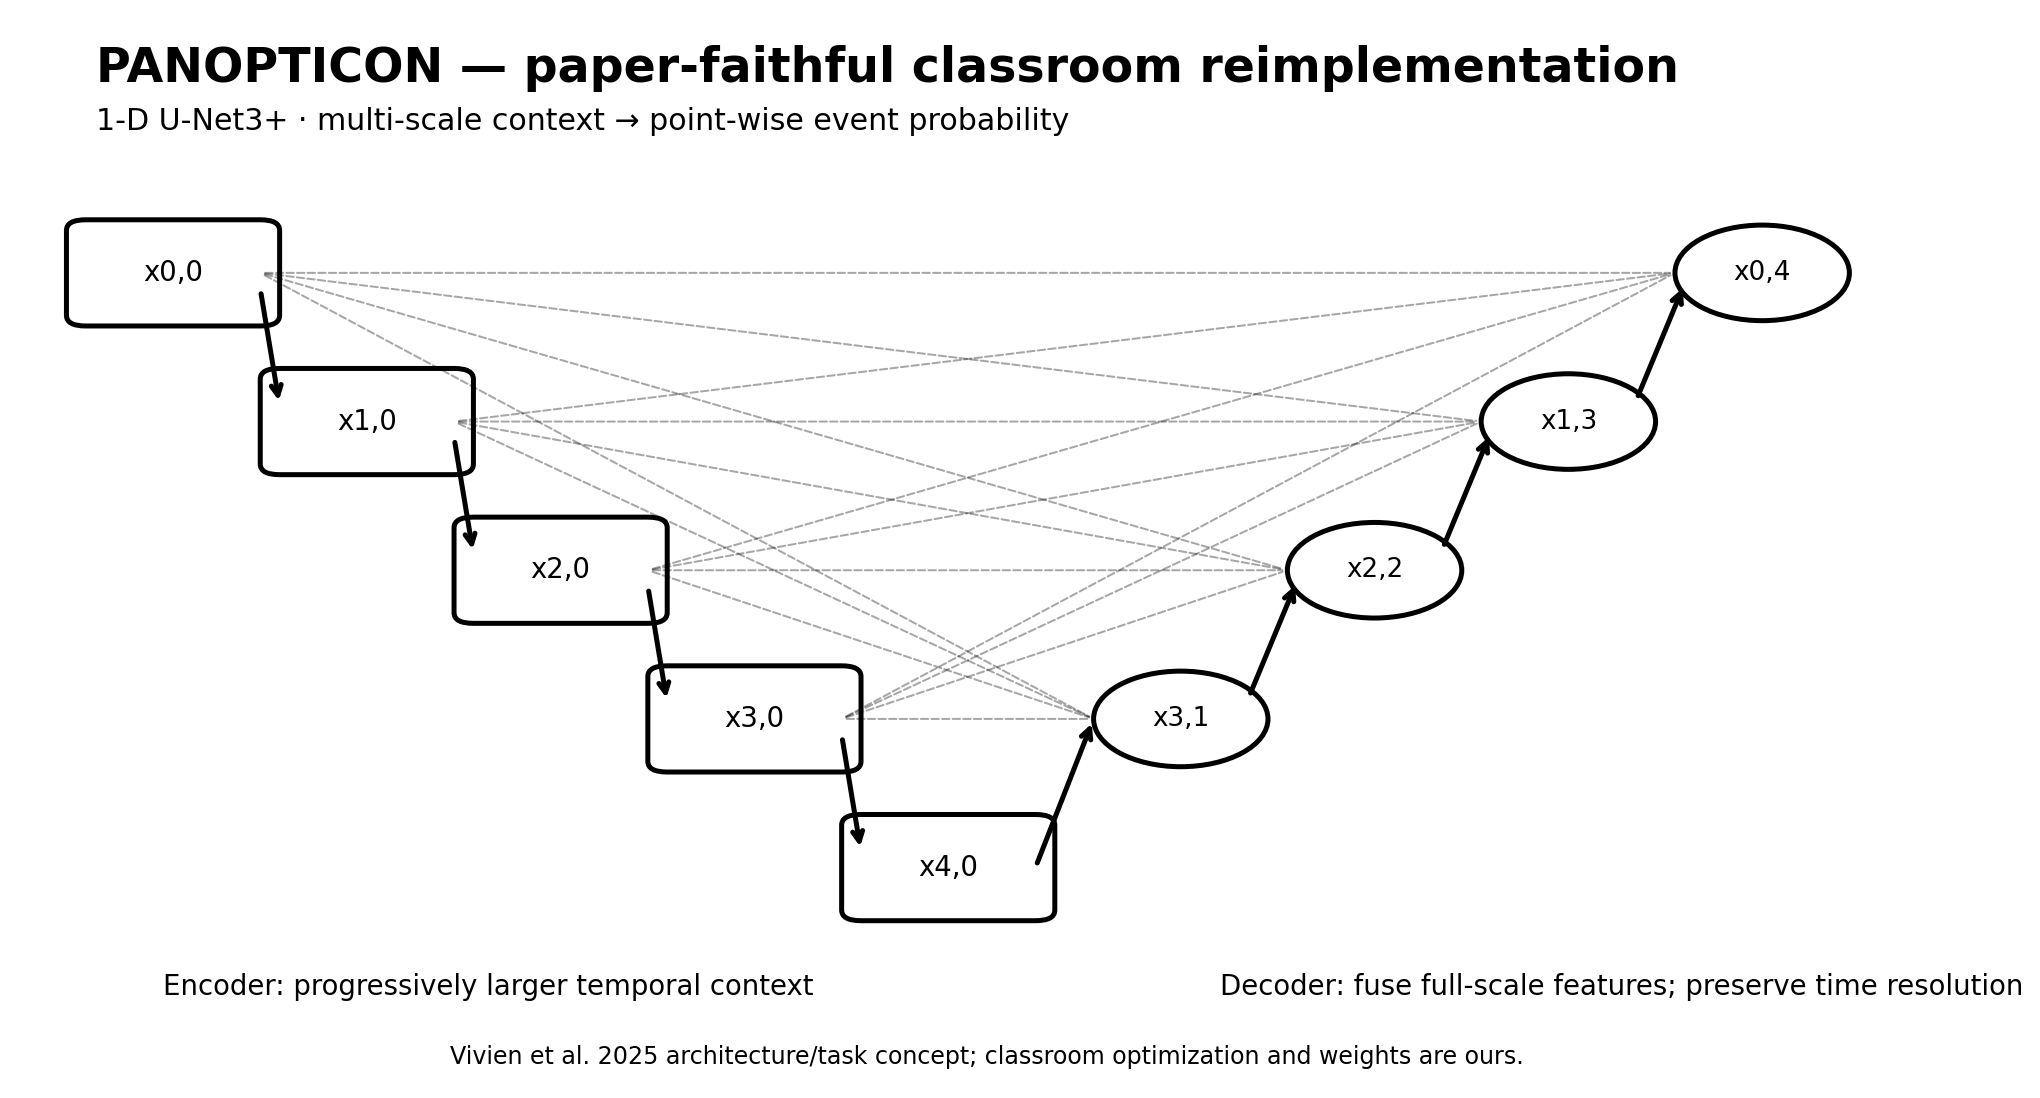

Classroom model parameters: 132,553
Classroom training history: [{'epoch': 1, 'loss': 0.5863020743642534, 'point_auc': 0.9902213206211292}, {'epoch': 2, 'loss': 0.46552795342036657, 'point_auc': 0.9900867739911268}, {'epoch': 3, 'loss': 0.39672146609851294, 'point_auc': 0.991096301671512}, {'epoch': 4, 'loss': 0.3301013835838863, 'point_auc': 0.9940527046487375}, {'epoch': 5, 'loss': 0.26689387517316, 'point_auc': 0.9919048067396027}]
PROVENANCE: PANOPTICON-inspired classroom reimplementation; not author code/weights.


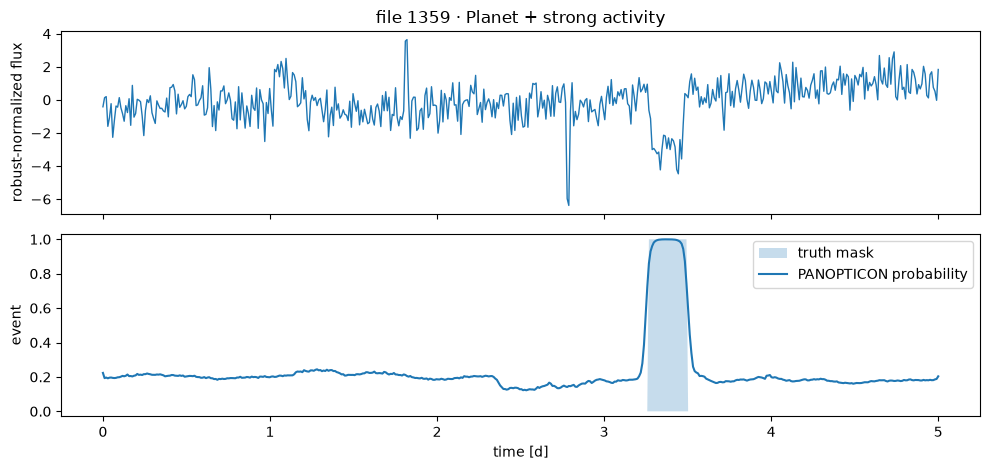

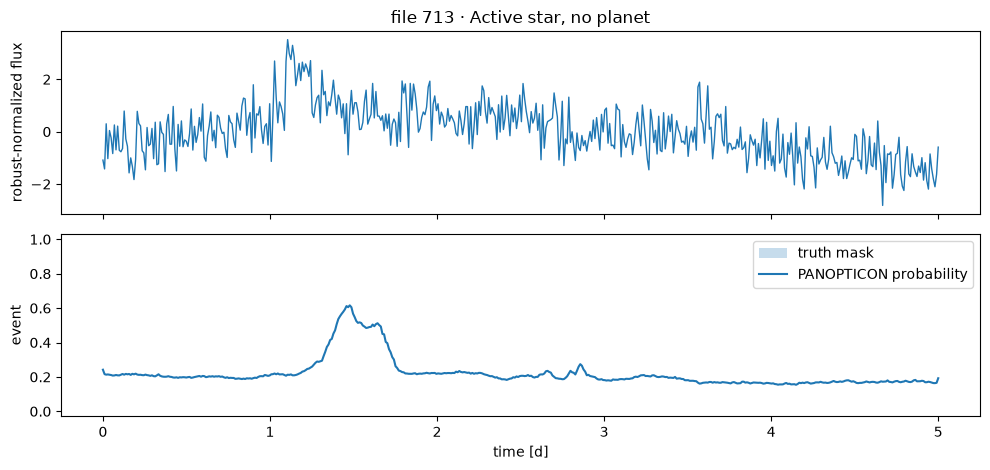

In [6]:
_pan_arch = ASSET_DIR / 'panopticon_unet3plus.png'
if _pan_arch.exists():
    ipydisplay(Image(filename=str(_pan_arch), width=900))

model, ck = load_panopticon(ROOT)
print('Classroom model parameters:', f"{sum(p.numel() for p in model.parameters()):,}")
print('Classroom training history:', ck['history'])
print('PROVENANCE: PANOPTICON-inspired classroom reimplementation; not author code/weights.')

_pan_eval = DATA_DIR / 'panopticon_eval_windows.npz'
z = np.load(_pan_eval)

choices = []
for lab in [3, 1]:
    matches = np.where(z['label'] == lab)[0]
    choices.append(matches[0])

for q in choices:
    x = torch.tensor(z['flux'][q:q+1, None, :], dtype=torch.float32)
    with torch.no_grad():
        prob = torch.sigmoid(model(x))[0, 0].cpu().numpy()
    show_window(
        z['time'][q], z['flux'][q], z['mask'][q], prob,
        title=f"file {z['file_id'][q]} · {CLASS_LABELS[int(z['label'][q])]}"
    )
    plt.show()

### Task 2B — threshold as a scientific decision

A threshold is not just an engineering parameter. If follow-up is scarce, false positives cost telescope time; if Earth analogues are rare, false negatives can be scientifically expensive.

Choose your own relative costs below and let the notebook find a threshold minimizing:

\[
C(t)=c_{\rm FP}\,{\rm FPR}(t)+c_{\rm FN}\,[1-{\rm TPR}(t)].
\]

**Before running:** should \(c_{\rm FN}\) be larger or smaller than \(c_{\rm FP}\) for an exploratory Earth-analogue search?

,threshold,FPR,TPR,cost
chosen operating point,0.66,17.0%,92.7%,0.461


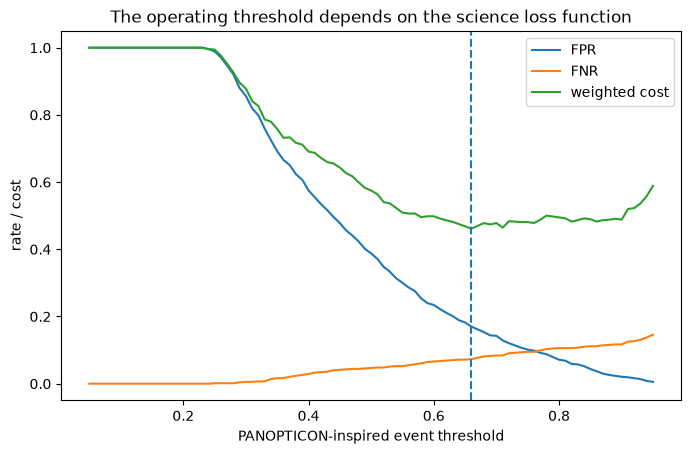

In [7]:
# STUDENT CHOICE: edit these two numbers.
false_positive_cost = 1.0
false_negative_cost = 4.0

y_true = (df.label >= 2).astype(int).to_numpy()
scores = df.panopticon_event_score.to_numpy()

thresholds = np.linspace(0.05, 0.95, 91)
rows = []
for t in thresholds:
    pred = scores >= t
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0,1]).ravel()
    fpr = fp / max(fp + tn, 1)
    tpr = tp / max(tp + fn, 1)
    cost = false_positive_cost*fpr + false_negative_cost*(1-tpr)
    rows.append((t, fpr, tpr, cost))

thr_scan = pd.DataFrame(rows, columns=['threshold','FPR','TPR','cost'])
best = thr_scan.loc[thr_scan.cost.idxmin()]
display(best.to_frame('chosen operating point').T.style.format({
    'threshold':'{:.2f}', 'FPR':'{:.1%}', 'TPR':'{:.1%}', 'cost':'{:.3f}'
}))

fig, ax = plt.subplots(figsize=(8,4.8))
ax.plot(thr_scan.threshold, thr_scan.FPR, label='FPR')
ax.plot(thr_scan.threshold, 1-thr_scan.TPR, label='FNR')
ax.plot(thr_scan.threshold, thr_scan.cost, label='weighted cost')
ax.axvline(best.threshold, ls='--')
ax.set_xlabel('PANOPTICON-inspired event threshold')
ax.set_ylabel('rate / cost')
ax.legend()
ax.set_title('The operating threshold depends on the science loss function')
plt.show()

Classroom event-level AUC: 0.958
Threshold calibrated to ~5% no-planet false alarms: 0.841
TPR = 89.0%; FPR = 5.1%


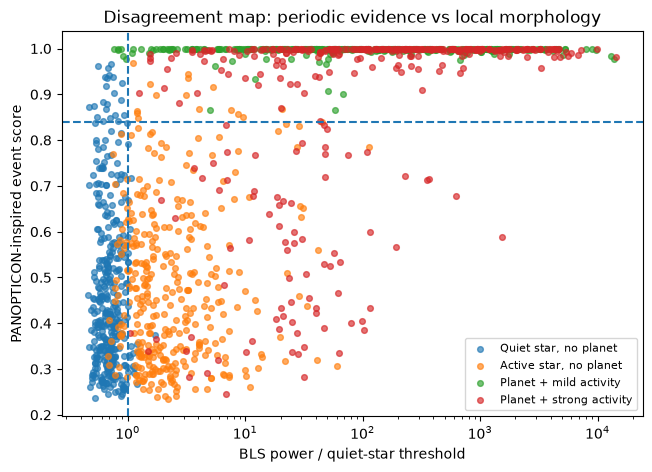

In [8]:
# Compare periodic evidence with local event morphology.
_metrics_path = MODEL_DIR / 'panopticon_metrics.json'
with open(_metrics_path) as f:
    m = json.load(f)

print(f"Classroom event-level AUC: {m['event_auc']:.3f}")
print(f"Threshold calibrated to ~5% no-planet false alarms: {m['threshold_5pct_no_planet']:.3f}")
print(f"TPR = {m['tpr']:.1%}; FPR = {m['fpr']:.1%}")

fig, ax = plt.subplots(figsize=(7.5, 5))
for c in range(4):
    s = df[df.label == c]
    ax.scatter(s.bls_power_ratio, s.panopticon_event_score,
               s=17, alpha=.65, label=CLASS_LABELS[c])
ax.axvline(1, ls='--')
ax.axhline(m['threshold_5pct_no_planet'], ls='--')
ax.set_xscale('log')
ax.set_xlabel('BLS power / quiet-star threshold')
ax.set_ylabel('PANOPTICON-inspired event score')
ax.legend(fontsize=8)
ax.set_title('Disagreement map: periodic evidence vs local morphology')
plt.show()

### Task 2C — disagreement is information

Find one scientific interpretation for each quadrant:

1. **BLS high / event score high**
2. **BLS high / event score low**
3. **BLS low / event score high**
4. **BLS low / event score low**

For quadrant 2 or 3, name the **next measurement** you would request.

> **YOUR ANSWER:**  
>

# Exercise 3 — ExoMiner++: detection is not vetting **[13 min]**

Now switch missions deliberately.

**ExoMiner++ is an official NASA TESS/SPOC vetting architecture**, designed to combine multiple diagnostic views. It does **not** consume the same information object as the PANOPTICON-inspired PLATO detector.

Conceptually:

\[
\text{candidate event}
+
\{\text{folded flux, difference image, centroid, trend, periodogram, spacecraft context, ...}\}
\rightarrow
P(\mathrm{planet}\mid\mathrm{diagnostics}).
\]

This is a useful lesson: **more relational views can change the scientific question from detection to explanation/vetting.**

### Task 3A
Inspect the architecture and determine which branches could veto an otherwise convincing transit-shaped signal.

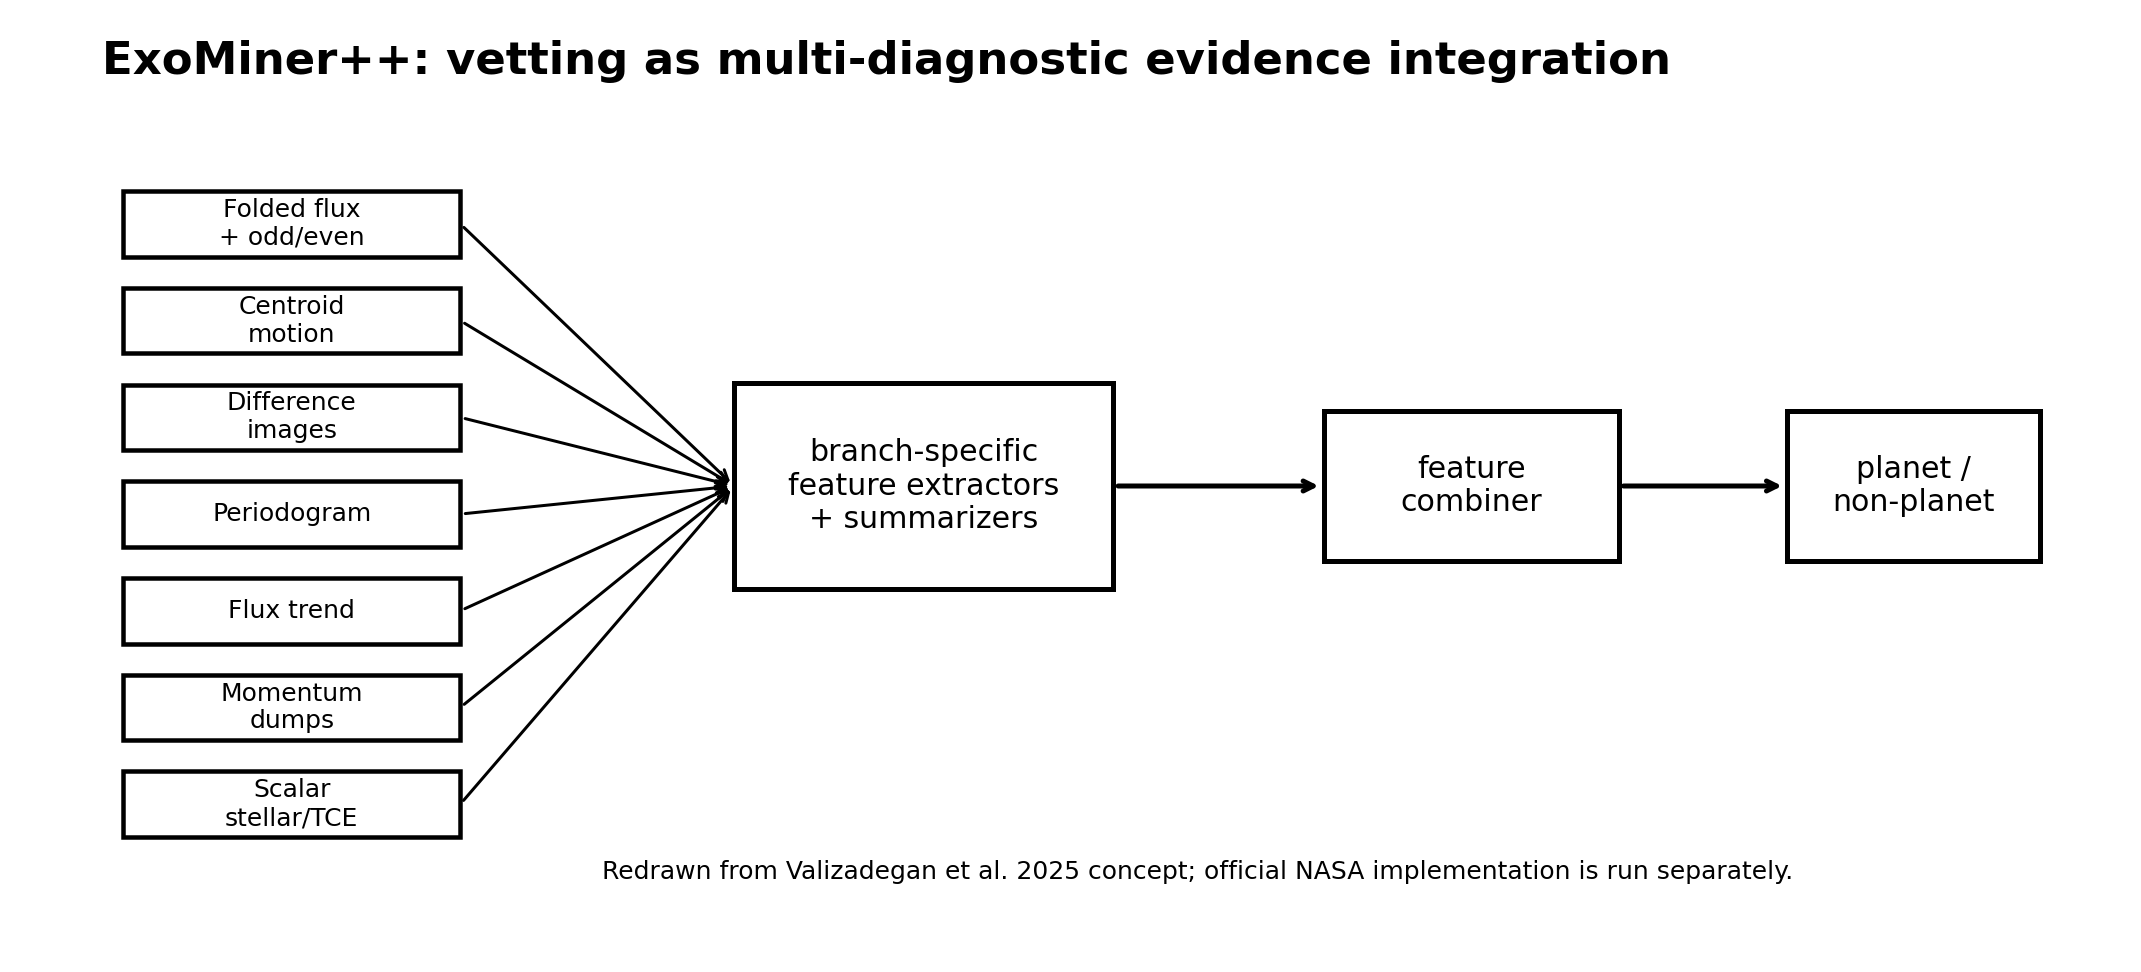

Prepared official-demo targets:
  TIC 261136679 S1  — π Mensae c, confirmed transiting super-Earth
  TIC 167526485 S6  — published EB / ellipsoidal-variation example

The official NASA ExoMiner++ pipeline is kept separate from the PLATO simulation
because it expects TESS/SPOC diagnostic products.


In [9]:
_exo_arch = ASSET_DIR / 'exominerpp_architecture.png'
if _exo_arch.exists():
    ipydisplay(Image(filename=str(_exo_arch), width=950))

print('Prepared official-demo targets:')
print('  TIC 261136679 S1  — π Mensae c, confirmed transiting super-Earth')
print('  TIC 167526485 S6  — published EB / ellipsoidal-variation example')
print()
print('The official NASA ExoMiner++ pipeline is kept separate from the PLATO simulation')
print('because it expects TESS/SPOC diagnostic products.')

In [10]:
# OFFICIAL NASA EXOMINER++ OUTPUT CHECK
# This notebook does not reimplement ExoMiner++.
hits = find_exominer_predictions(ROOT)

if not hits:
    print('No cached official ExoMiner++ prediction output is present in this package yet.')
    print('For the live school demo, the instructor can pre-run:')
    print(f'  cd "{ROOT}"')
    print('  ./exominer_official/run_exominer_official.sh')
    print()
    print('Students can still complete the diagnostic reasoning task below.')
else:
    print('Official ExoMiner++ prediction file(s) found:')
    for h in hits:
        print(' ', h)
    display(pd.read_csv(hits[0]).head(20))

No cached official ExoMiner++ prediction output is present in this package yet.
For the live school demo, the instructor can pre-run:
  cd "<repo-root>"
  ./exominer_official/run_exominer_official.sh

Students can still complete the diagnostic reasoning task below.


### Task 3B — diagnostic ablation

For each hypothetical candidate, predict whether the ExoMiner++ planet score should **rise**, **fall**, or remain **ambiguous**, and justify the decisive relation.

| Candidate | Transit shape | Difference image / centroid | Spacecraft events | Your expectation |
|---|---|---|---|---|
| A | convincing | on target | clean | ? |
| B | convincing | offset from target | clean | ? |
| C | convincing | on target | repeated momentum-dump coincidence | ? |
| D | weak | on target | clean | ? |

**Question:** Why would it be scientifically wrong to feed a PLATO light curve directly into the TESS/SPOC ExoMiner++ pipeline and call the output a fair benchmark?

> **YOUR ANSWER:**  
>

# Exercise 4 — Neural Processes: **why locality matters for a transit** **[15 min]**

The result from the previous notebook is important: a tiny **mean-pooled CNP is not an appropriate raw transit reconstructor**.

A vanilla CNP forms one global representation,

\[
r_i=h_\theta(x_i,y_i), \qquad
r=\frac{1}{N_C}\sum_i r_i,
\qquad
p(y_\*|x_\*,C)=g_\phi(x_\*,r).
\]

For a localized transit, only a small fraction of the context may contain ingress, bottom, or egress. Mean pooling compresses all context points into the **same vector for every target location**, so the localized event can be diluted. This is closely related to the underfitting problem that motivated **Attentive Neural Processes (ANPs)**.

Two common fixes are:

- **ANP:** each target \(x_\*\) attends to context points relevant to that target;
- **ConvCNP:** the context set is embedded into a **local function-space representation** and processed convolutionally, preserving translation-equivariant local structure.

### What we do here

For a short 90-minute lab, we use a small **ConvCNP-style classroom model** because it is fast and makes the locality issue visible.

> **Provenance:** this is our classroom implementation inspired by Gordon et al. (2019), not the authors' released code.  
> It is an interpolation/inference exercise, **not a transit-discovery pipeline**.

### Task 4A — prediction before running

Why should a single global mean-pooled representation struggle more than a local functional representation with a narrow transit?

> **YOUR ANSWER:**  
>


✓ Tiny ConvCNP-style model trained in 6.35 s
Train/test tasks: 80 / 20
Learned set-convolution length scale: 0.023089280351996422


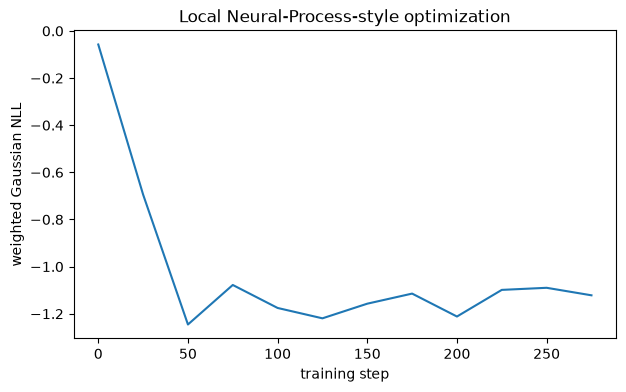

In [11]:
class TinyConvCNP(nn.Module):
    # Compact ConvCNP-style classroom model; not author code.
    def __init__(self, grid, ell=0.025, hidden=48):
        super().__init__()
        self.register_buffer('grid', grid)
        self.log_ell = nn.Parameter(torch.tensor(math.log(ell), dtype=torch.float32))
        self.net = nn.Sequential(
            nn.Conv1d(2, hidden, 5, padding=2), nn.ReLU(),
            nn.Conv1d(hidden, hidden, 5, padding=4, dilation=2), nn.ReLU(),
            nn.Conv1d(hidden, hidden, 5, padding=8, dilation=4), nn.ReLU(),
            nn.Conv1d(hidden, hidden, 5, padding=16, dilation=8), nn.ReLU(),
            nn.Conv1d(hidden, 2, 1)
        )

    def forward(self, x_context, y_context):
        # x_context, y_context: [B, Nc], x normalized to [-1,1]
        ell = torch.exp(self.log_ell).clamp(0.008, 0.08)

        # Set convolution: irregular context -> local representation on a grid.
        d = (self.grid[None, :, None] - x_context[:, None, :]) / ell
        w = torch.exp(-0.5 * d**2)

        density = w.sum(dim=-1)
        signal = (w * y_context[:, None, :]).sum(dim=-1) / (density + 1e-6)

        # The density channel exposes where the context supports inference.
        representation = torch.stack([signal, torch.log1p(density)], dim=1)

        out = self.net(representation)
        mu = out[:, 0, :]
        sigma = 0.04 + F.softplus(out[:, 1, :])
        return mu, sigma, density


_np = np.load(DATA_DIR / 'panopticon_eval_windows.npz')

_t = torch.tensor(_np['time'], dtype=torch.float32)
_y = torch.tensor(np.clip(_np['flux'], -20, 10), dtype=torch.float32)
_labels = _np['label'].astype(int)

_tmin = _t.min(dim=1, keepdim=True).values
_tmax = _t.max(dim=1, keepdim=True).values
_tn = 2 * (_t - _tmin) / (_tmax - _tmin) - 1

Y_SCALE = 5.0
_yn = _y / Y_SCALE

# Stratified 80/20 split: 20 train + 5 test from each of C0..C3.
train_ids, test_ids = [], []
for c in np.unique(_labels):
    ids = np.where(_labels == c)[0]
    train_ids.extend(ids[:20])
    test_ids.extend(ids[20:])
train_ids = np.array(train_ids)
test_ids = np.array(test_ids)

grid = torch.linspace(-1, 1, _tn.shape[1])
convcnp = TinyConvCNP(grid)

optimizer = torch.optim.Adam(convcnp.parameters(), lr=2e-3)
rng_np = np.random.default_rng(7)
torch.manual_seed(7)

def _training_context(idx, n_context=96):
    # For this supervised interpolation exercise, simulated planet tasks
    # deliberately include a few labelled transit samples in the context.
    # The truth mask is used only to build training examples; it is NOT
    # passed to the model as an input feature.
    mask = _np['mask'][idx].astype(bool)
    inside = np.where(mask)[0]
    outside = np.where(~mask)[0]

    chosen = []
    if _labels[idx] >= 2 and len(inside):
        n_in = min(8, len(inside))
        chosen.extend(rng_np.choice(inside, size=n_in, replace=False).tolist())

    remaining = n_context - len(chosen)
    chosen.extend(rng_np.choice(outside, size=remaining, replace=False).tolist())
    return np.array(sorted(chosen))

history = []
start = _time.time()

for step in range(300):
    batch_ids = rng_np.choice(train_ids, size=12, replace=True)

    xc, yc, yt = [], [], []
    for idx in batch_ids:
        ci = _training_context(idx)
        xc.append(_tn[idx, ci])
        yc.append(_yn[idx, ci])
        yt.append(_yn[idx])

    xc = torch.stack(xc)
    yc = torch.stack(yc)
    yt = torch.stack(yt)

    mu, sigma, density = convcnp(xc, yc)

    # Simulations provide a truth mask, so rare transit samples are up-weighted.
    # The mask is NOT an inference input.
    weight = torch.ones_like(yt)
    for b, idx in enumerate(batch_ids):
        m = torch.tensor(_np['mask'][idx].astype(bool))
        weight[b, m] = 8.0

    nll = weight * (0.5 * ((yt - mu) / sigma)**2 + torch.log(sigma))
    loss = nll.sum() / weight.sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 25 == 0:
        history.append((step, float(loss.detach())))

print(f'✓ Tiny ConvCNP-style model trained in {_time.time()-start:.2f} s')
print('Train/test tasks:', len(train_ids), '/', len(test_ids))
print('Learned set-convolution length scale:',
      float(torch.exp(convcnp.log_ell).detach()))

hist = pd.DataFrame(history, columns=['step', 'weighted_NLL'])
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(hist.step, hist.weighted_NLL)
ax.set_xlabel('training step')
ax.set_ylabel('weighted Gaussian NLL')
ax.set_title('Local Neural-Process-style optimization')
plt.show()


### Task 4B — can a local NP representation preserve the transit?

Choose a **held-out planet light curve** and make two context sets:

1. **event-aware context:** sparse observations including a few transit samples;
2. **transit-blind context:** observations deliberately exclude the transit **and a margin around it**.

This is the key information experiment.

### Before running

Predict what should happen:

- Should the event-aware context permit recovery of the transit morphology?
- Should the transit-blind context determine a unique object-specific transit?

> **YOUR PREDICTION:**  
>


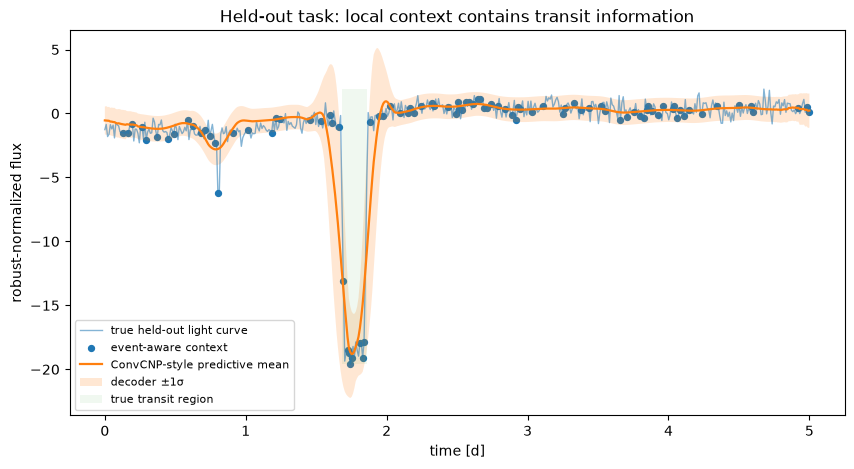

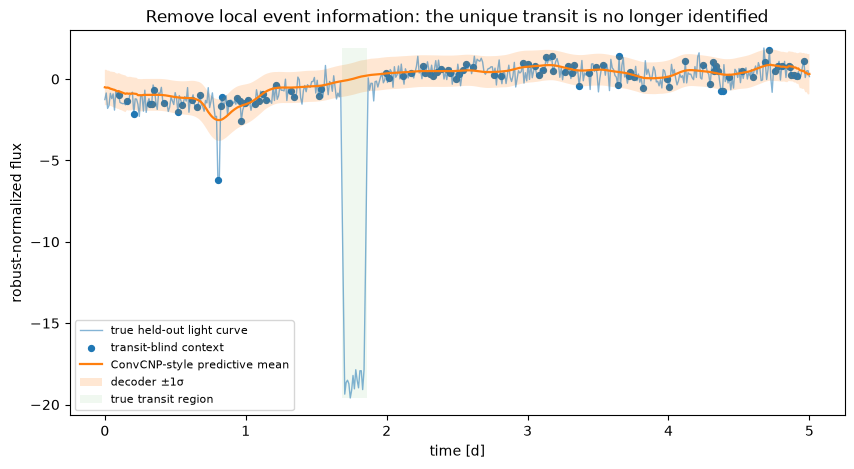

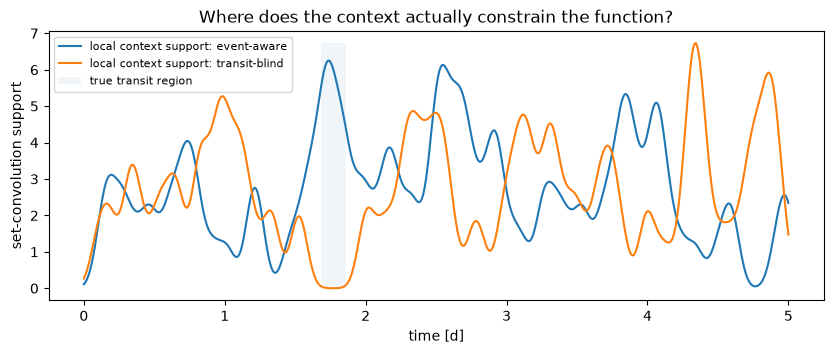

Transit-region RMSE — event-aware context : 2.6199445724487305
Transit-region RMSE — transit-blind context: 17.20058250427246
Mean local support in transit — event-aware: 5.616886138916016
Mean local support in transit — blind      : 0.01924707368016243


In [12]:
planet_test = np.array([i for i in test_ids if _labels[i] >= 2])
q = int(planet_test[0])

truth_mask = _np['mask'][q].astype(bool)
inside = np.where(truth_mask)[0]
outside = np.where(~truth_mask)[0]

rng_demo = np.random.default_rng(19)
n_context = 96

# Event-aware context: include a few transit points.
n_in = min(8, len(inside))
event_ctx = np.concatenate([
    rng_demo.choice(inside, size=n_in, replace=False),
    rng_demo.choice(outside, size=n_context-n_in, replace=False)
])
event_ctx = np.sort(event_ctx)

# Transit-blind context: remove event plus a margin.
all_idx = np.arange(len(truth_mask))
lo = max(0, inside.min() - 12)
hi = min(len(truth_mask)-1, inside.max() + 12)
far_from_event = np.where((all_idx < lo) | (all_idx > hi))[0]
blind_ctx = np.sort(rng_demo.choice(far_from_event, size=n_context, replace=False))

def _convcnp_predict(context_idx):
    with torch.no_grad():
        mu, sig, density = convcnp(
            _tn[q, context_idx][None, :],
            _yn[q, context_idx][None, :]
        )
    return (
        mu[0].numpy() * Y_SCALE,
        sig[0].numpy() * Y_SCALE,
        density[0].numpy()
    )

mu_event, sig_event, support_event = _convcnp_predict(event_ctx)
mu_blind, sig_blind, support_blind = _convcnp_predict(blind_ctx)

t_plot = _np['time'][q]
y_plot = _np['flux'][q]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(t_plot, y_plot, lw=1, alpha=.55, label='true held-out light curve')
ax.scatter(t_plot[event_ctx], y_plot[event_ctx], s=18, label='event-aware context')
ax.plot(t_plot, mu_event, lw=1.6, label='ConvCNP-style predictive mean')
ax.fill_between(t_plot, mu_event-sig_event, mu_event+sig_event,
                alpha=.18, label='decoder ±1σ')
ax.fill_between(t_plot, y_plot.min(), y_plot.max(),
                where=truth_mask, alpha=.07, label='true transit region')
ax.set_xlabel('time [d]')
ax.set_ylabel('robust-normalized flux')
ax.set_title('Held-out task: local context contains transit information')
ax.legend(fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(t_plot, y_plot, lw=1, alpha=.55, label='true held-out light curve')
ax.scatter(t_plot[blind_ctx], y_plot[blind_ctx], s=18, label='transit-blind context')
ax.plot(t_plot, mu_blind, lw=1.6, label='ConvCNP-style predictive mean')
ax.fill_between(t_plot, mu_blind-sig_blind, mu_blind+sig_blind,
                alpha=.18, label='decoder ±1σ')
ax.fill_between(t_plot, y_plot.min(), y_plot.max(),
                where=truth_mask, alpha=.07, label='true transit region')
ax.set_xlabel('time [d]')
ax.set_ylabel('robust-normalized flux')
ax.set_title('Remove local event information: the unique transit is no longer identified')
ax.legend(fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(10,3.5))
ax.plot(t_plot, support_event, label='local context support: event-aware')
ax.plot(t_plot, support_blind, label='local context support: transit-blind')
ax.fill_between(t_plot, 0, max(support_event.max(), support_blind.max()),
                where=truth_mask, alpha=.07, label='true transit region')
ax.set_xlabel('time [d]')
ax.set_ylabel('set-convolution support')
ax.set_title('Where does the context actually constrain the function?')
ax.legend(fontsize=8)
plt.show()

true_event_flux = y_plot[truth_mask]
rmse_event = np.sqrt(np.mean((mu_event[truth_mask] - true_event_flux)**2))
rmse_blind = np.sqrt(np.mean((mu_blind[truth_mask] - true_event_flux)**2))

print('Transit-region RMSE — event-aware context :', float(rmse_event))
print('Transit-region RMSE — transit-blind context:', float(rmse_blind))
print('Mean local support in transit — event-aware:',
      float(np.mean(support_event[truth_mask])))
print('Mean local support in transit — blind      :',
      float(np.mean(support_blind[truth_mask])))


### What the experiment means

The **event-aware** case can recover the localized dip because the representation retains **where** the informative context points lie.

The **transit-blind** case should *not* magically recover this object's unique transit. If the relevant object-specific evidence is absent from the context, the network can only use its learned population prior.

A second lesson is equally important: **do not automatically trust the decoder's Gaussian \(\sigma\) as epistemic uncertainty.** A compact classroom model can be overconfident outside its supported context. The third plot therefore exposes the **local context-support density** explicitly.

### Task 4C — answer these questions

1. Why does the event-aware context reconstruct the transit much better than the blind context?
2. Why would it be scientifically wrong to demand that the blind context reconstruct the correct transit?
3. If the decoder reports a small \(\sigma\) where context support is almost zero, what kind of failure is this?
4. What would you add for better uncertainty: latent NP, ensemble, calibrated likelihood, posterior predictive checks, or something else?

> **YOUR ANSWER:**  
>


### Task 4D — connect this to **Attentive Neural Processes**

ConvCNP and ANP attack the same representational weakness in different ways:

\[
\text{global mean pooling}
\quad\longrightarrow\quad
\begin{cases}
\text{local functional representation} & \text{(ConvCNP)}\\
\text{target-to-context attention} & \text{(ANP)}
\end{cases}
\]

For a transit, an ANP target near ingress can assign high weight to context points near ingress rather than sharing one averaged context vector with the entire light curve.

**Questions**

1. What relation does target-to-context attention preserve that global CNP pooling weakens?
2. Why is an attention weight **not automatically a physical causal relation**?
3. Propose an instrument-aware context token for a PLATO-like application.

One possible token is

\[
(t_i,\ f_i,\ \sigma_i,\ \mathrm{cadence/mask},\
\mathrm{camera},\ \mathrm{stellar\ context},\ H_i).
\]

4. For a real scientific model, would you rather predict raw flux, infer physical transit parameters and pass them through a forward model, or do both? Explain what each choice preserves.

> **YOUR ANSWER:**  
>


# Exercise 5 — Blind mission board: only **five follow-up slots** **[15 min]**

Now integrate everything.

You have 12 candidates with:
- BLS evidence;
- PANOPTICON-inspired event score;
- activity/noise context.

You may select only **five** objects.

For each selected candidate, request **one** new information source with the highest expected scientific information gain:

- another transit epoch;
- RV;
- colour dependence;
- centroid / difference-image equivalent;
- stellar activity indicator;
- higher cadence;
- or another well-justified diagnostic.

The goal is not maximum classification accuracy. It is a **decision under constrained observing resources**.

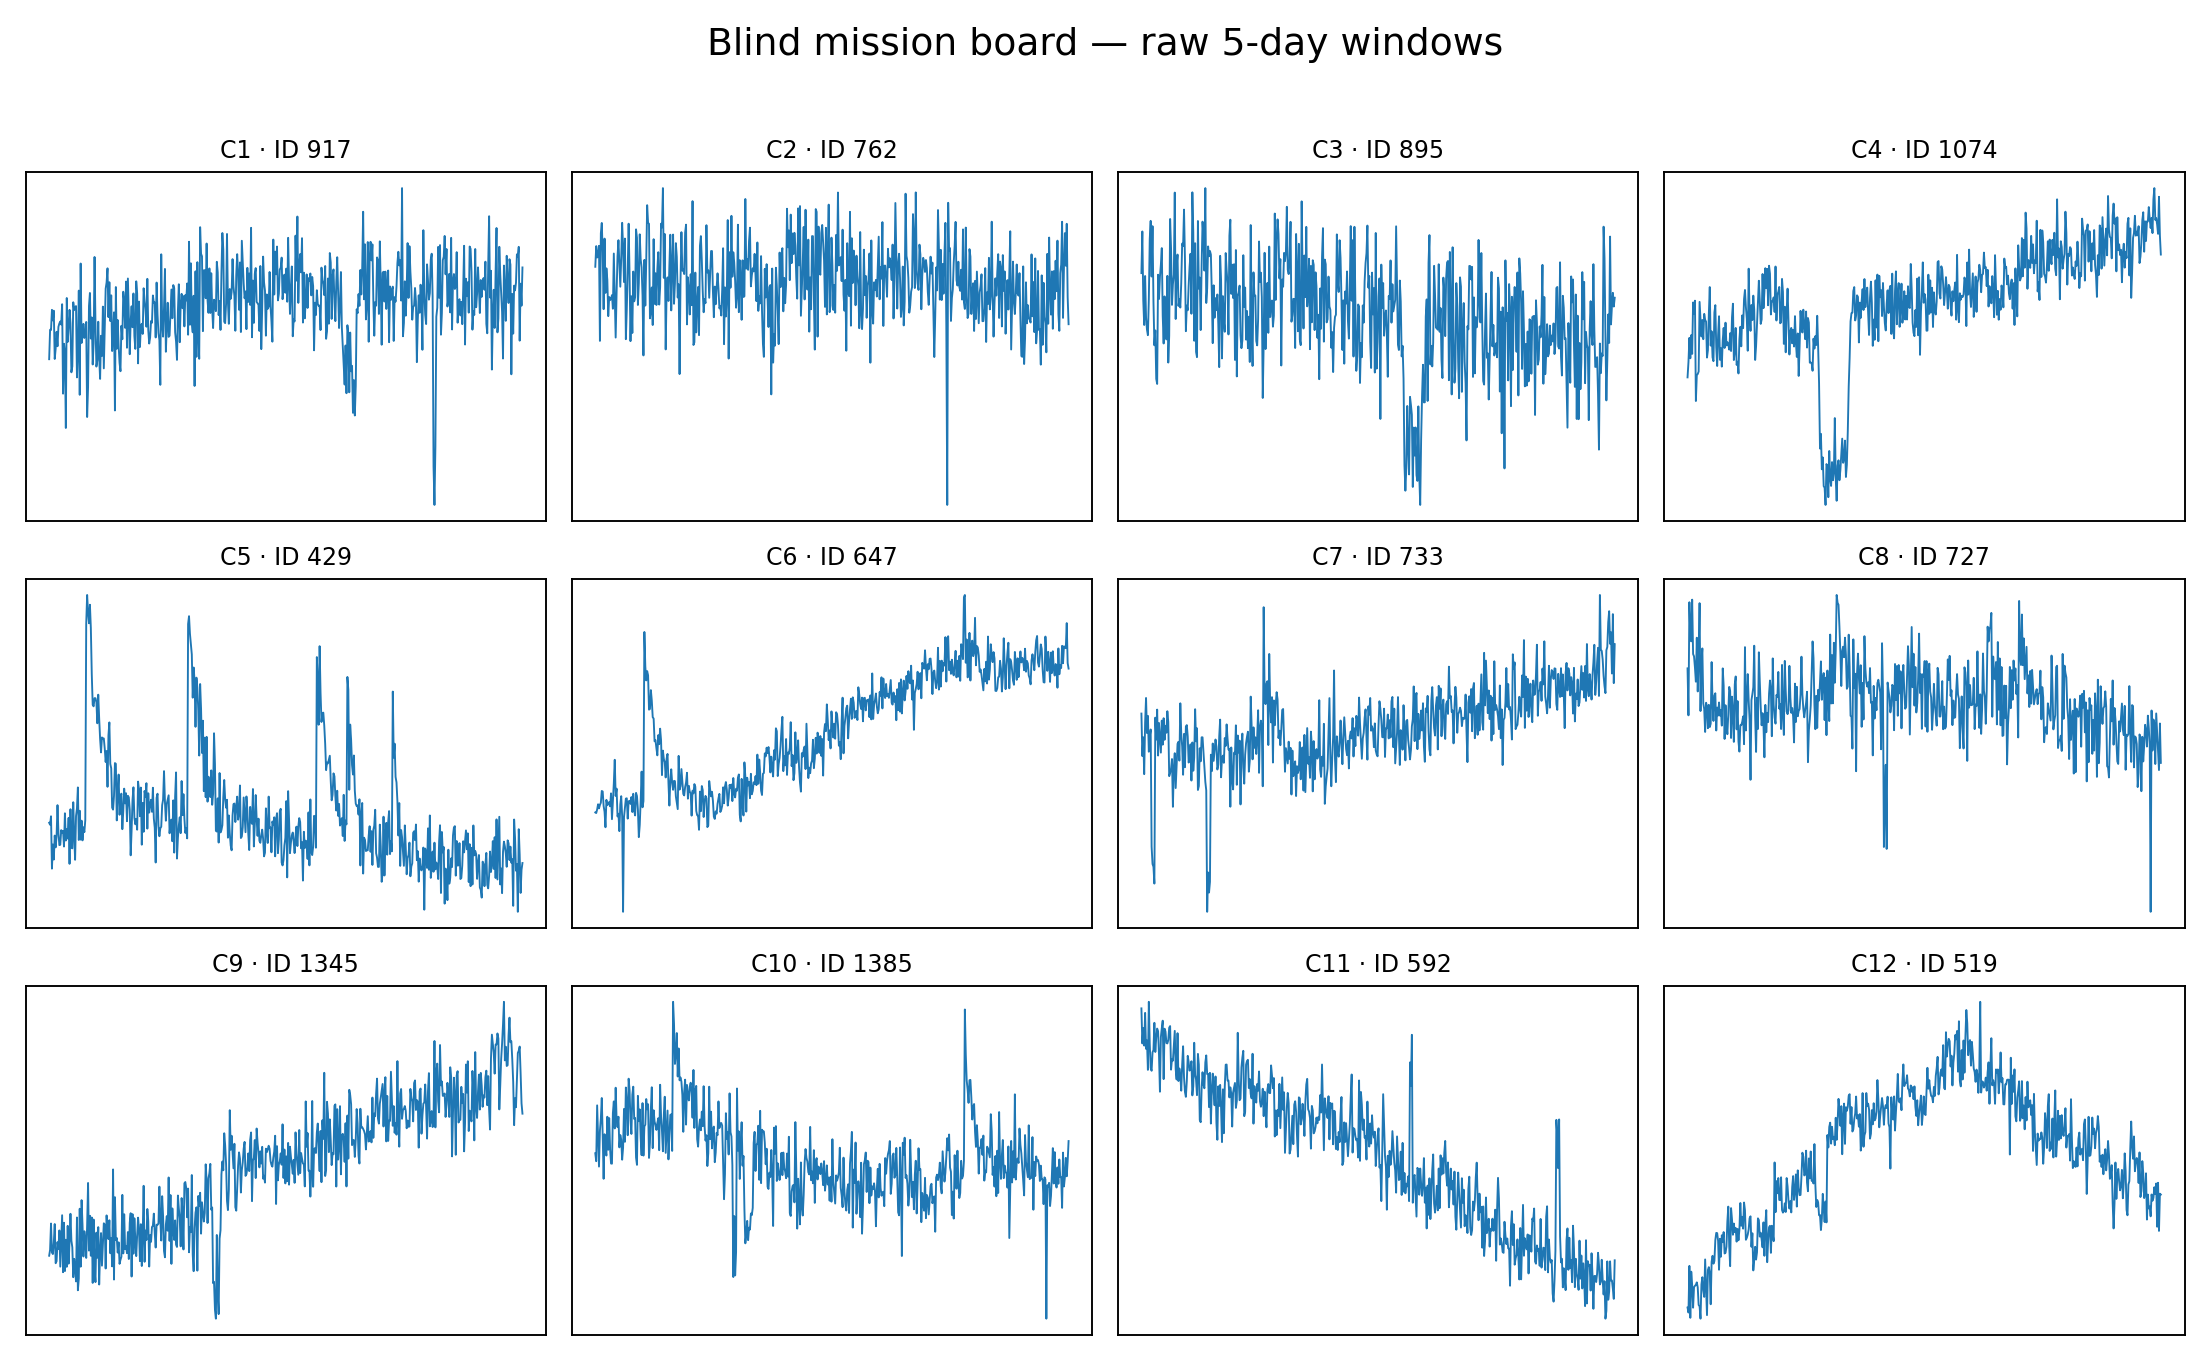

,file_id,bls_power_ratio,bls_period,bls_depth_ppm,panopticon_event_score,act_rms,rotation_period_days,sigma_ppm,teff,logg
0,917,5.56,6.146404,33.742376,0.963,50.6,28.340000,13.6,5818.600000,4.228000
1,762,5.00,8.677454,38.000089,0.867,73.7,26.880000,35.4,5216.800000,4.237000
2,895,0.82,34.432533,51.603721,0.999,46.2,20.020000,24.4,6141.100000,4.410000
3,1074,0.88,1.969961,13.069363,0.999,65.9,30.360000,6.8,5875.900000,4.223000
4,429,113.09,0.541281,34.962403,0.786,429.8,11.820000,98.9,5549.700000,4.300000
5,647,60.62,0.694681,28.998369,0.306,537.4,14.030000,72.0,5973.500000,4.396000
6,733,1.11,0.555714,3.275949,0.968,137.9,18.960000,25.3,5237.500000,4.220000
7,727,3.26,0.542871,5.949940,0.944,219.0,18.580000,85.0,5924.800000,4.533000
8,1345,1535.38,4.446997,581.510960,0.589,495.8,19.950000,102.0,5430.900000,4.524000
9,1385,625.17,4.111513,357.915082,0.679,343.0,15.470000,83.6,6189.300000,4.526000


In [13]:
_board_img = ASSET_DIR / 'mission_board.png'
if _board_img.exists():
    ipydisplay(Image(filename=str(_board_img), width=1000))

board = pd.read_csv(DATA_DIR / 'challenge_candidates.csv')
display(board.style.format({
    'bls_power_ratio': '{:.2f}',
    'panopticon_event_score': '{:.3f}',
    'act_rms': '{:.1f}',
    'sigma_ppm': '{:.1f}'
}))

In [14]:
# === GROUP DECISION: EDIT THIS CELL ===
# Put exactly five file IDs in the list.
selected_file_ids = []

# For each selected ID, state ONE requested follow-up source.
# Example only: {123: 'RV', 456: 'another transit epoch'}
requested_information = {}

# Give one sentence of rationale per target.
rationale = {}

print('Selected:', selected_file_ids)
print('Number selected:', len(selected_file_ids))

if selected_file_ids and len(selected_file_ids) != 5:
    print('⚠ Mission rule: select exactly five.')

Selected: []
Number selected: 0


### Mission-board questions

1. Did you prioritize **agreement** between BLS and event morphology, or **disagreement** that could yield high information gain?
2. Which selected target has the largest epistemic uncertainty?
3. Which follow-up measurement would most directly distinguish **planet** from **stellar/instrumental false positive**?
4. Would ExoMiner++-style diagnostics change your ranking if analogous PLATO diagnostics existed?

> **GROUP ANSWER:**  
>

# Final synthesis — **3 min**

The four methods are **not interchangeable classifiers**:

| Method | Representation | Relation preserved | Typical output |
|---|---|---|---|
| BLS | periodic box template | phase-coherent repetition | period / detection statistic |
| PANOPTICON-inspired U-Net3+ | local multi-scale feature map | event morphology across scales | point-wise event probability |
| official ExoMiner++ | multiple TESS/SPOC diagnostic branches | relations among independent vetting views | planet-vetting score |
| ConvCNP-style NP | local functional context representation | local context–target structure | conditional function prediction + support |

A central information-theory constraint is:

\[
I(S;\hat Y\mid D)\le I(S;Z\mid D)\le I(S;X\mid D).
\]

A model can exploit priors learned from \(D\), but it cannot recover object-specific information that the observing operator or representation has already destroyed.

## Exit ticket
Complete in **one sentence**:

> **“A scientifically good latent representation should preserve …”**

**YOUR SENTENCE:**


## References and provenance

- Kovács, Zucker & Mazeh (2002), *A box-fitting algorithm in the search for periodic transits*, A&A 391, 369.
- Vivien et al. (2025), **PANOPTICON: A novel deep learning model to detect single transit events with no prior data filtering in PLATO light curves**, A&A 694, A293, DOI: 10.1051/0004-6361/202452124.  
  **This notebook does not claim to use author code or author weights.**
- Valizadegan et al. (2025), **ExoMiner++: Enhanced Transit Classification and a New Vetting Catalog for 2-Minute TESS Data**, arXiv:2502.09790 / AJ 170.  
  Official software: NASA `nasa/Exominer` repository; official pipeline is intended for TESS/SPOC products.
- Garnelo et al. (2018), **Neural Processes**, arXiv:1807.01622.
- Kim et al. (2019), **Attentive Neural Processes**, arXiv:1901.05761.
- Gordon et al. (2019), **Convolutional Conditional Neural Processes**, arXiv:1910.13556.

### Reproducibility rule
When presenting results, always label whether a result comes from:
**(i)** the student's simulation/analysis, **(ii)** a classroom reimplementation, **(iii)** an official released pipeline, or **(iv)** a conceptual/model-design exercise.
